In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

In [3]:
df = pd.read_csv("../data/energy_data.csv")

df.columns = df.columns.str.strip()

df[df.columns[0]] = pd.to_datetime(df[df.columns[0]], errors='coerce')

df.set_index(df.columns[0], inplace=True)

print("Columns:", df.columns)
df.head()

Columns: Index(['fridge', 'ac', 'lights', 'microwave', 'total_power'], dtype='object')


,fridge,ac,lights,microwave,total_power
timestamp,,,,,
2023-01-01 00:00:00,119,0,73,0,192
2023-01-01 01:00:00,134,0,0,0,134
2023-01-01 02:00:00,0,1551,73,0,1624
2023-01-01 03:00:00,0,0,66,0,66
2023-01-01 04:00:00,83,0,86,0,169


In [4]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (4321, 5)

Missing Values:
 fridge         0
ac             0
lights         0
microwave      0
total_power    0
dtype: int64

Duplicate Rows: 1148


In [5]:

numeric_cols = df.select_dtypes(include=['number']).columns

print("Numeric Columns Found:", numeric_cols)

energy_col = numeric_cols[0]

print("Using Column for Analysis:", energy_col)

Numeric Columns Found: Index(['fridge', 'ac', 'lights', 'microwave', 'total_power'], dtype='object')
Using Column for Analysis: fridge


In [6]:
df[energy_col].describe()

count    4321.000000
mean       87.443879
std        67.326252
min         0.000000
25%         0.000000
50%        93.000000
75%       145.000000
max       199.000000
Name: fridge, dtype: float64

In [7]:
print("Mean:", df[energy_col].mean())
print("Standard Deviation:", df[energy_col].std())
print("Skewness:", skew(df[energy_col]))
print("Kurtosis:", kurtosis(df[energy_col]))

Mean: 87.44387873177506
Standard Deviation: 67.32625210391073
Skewness: -0.05815269927295844
Kurtosis: -1.3532411909772382


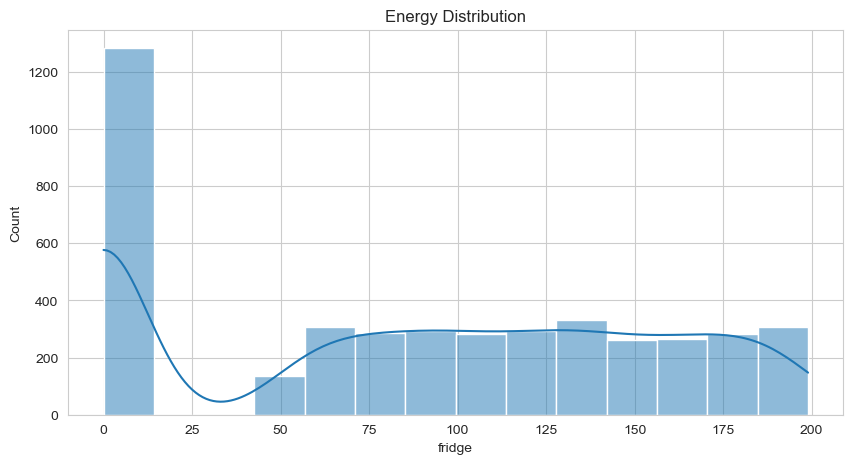

In [8]:
sns.histplot(df[energy_col], kde=True)
plt.title("Energy Distribution")
plt.show()

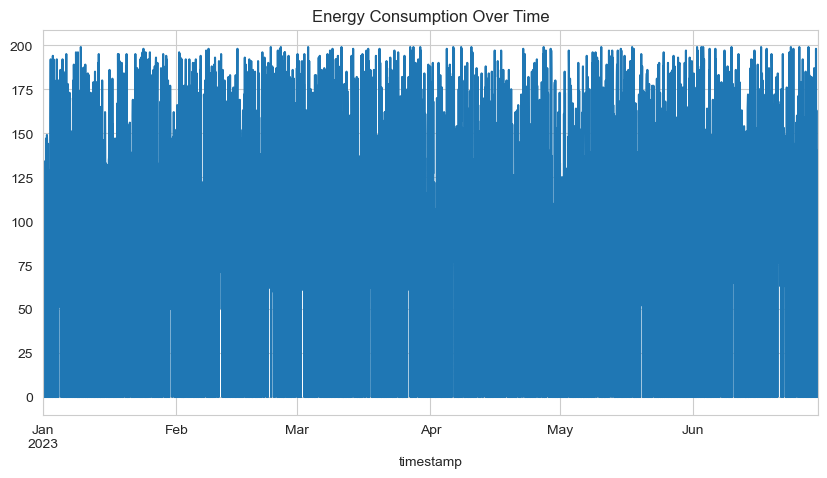

In [9]:
df[energy_col].plot()
plt.title("Energy Consumption Over Time")
plt.show()

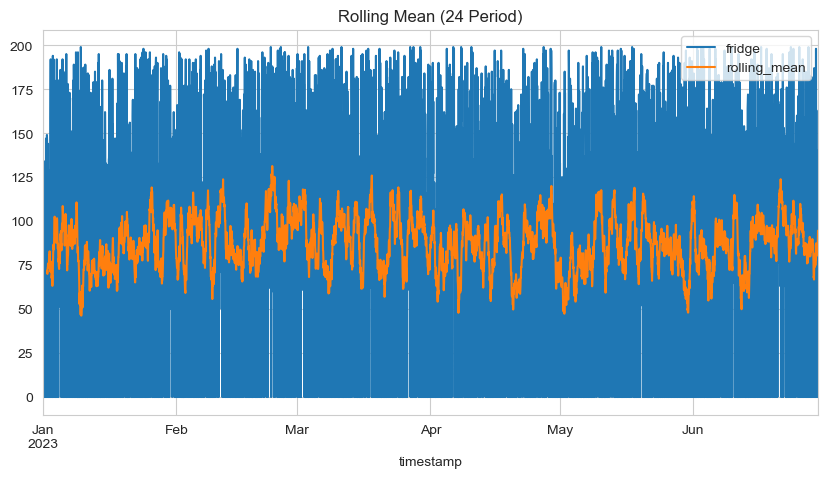

In [10]:
df['rolling_mean'] = df[energy_col].rolling(24).mean()

df[[energy_col, 'rolling_mean']].plot()
plt.title("Rolling Mean (24 Period)")
plt.show()


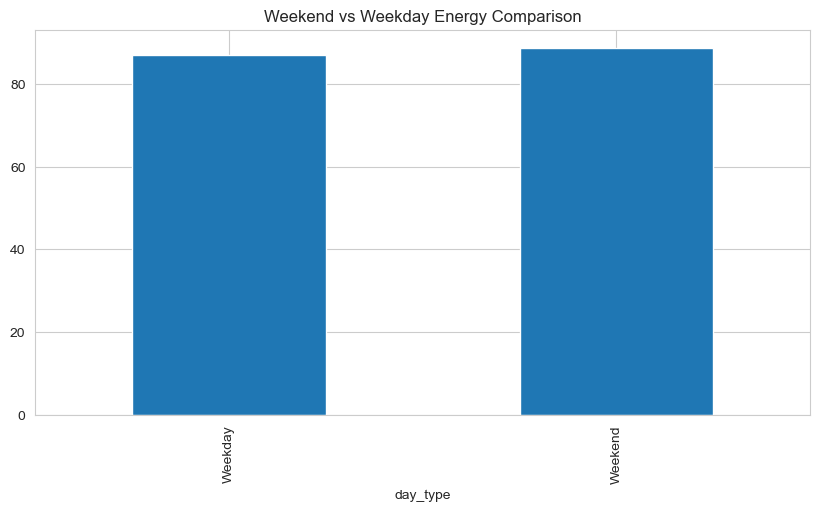

In [11]:
df['day_type'] = np.where(df.index.weekday >= 5, "Weekend", "Weekday")

df.groupby('day_type')[energy_col].mean().plot(kind='bar')
plt.title("Weekend vs Weekday Energy Comparison")
plt.show()

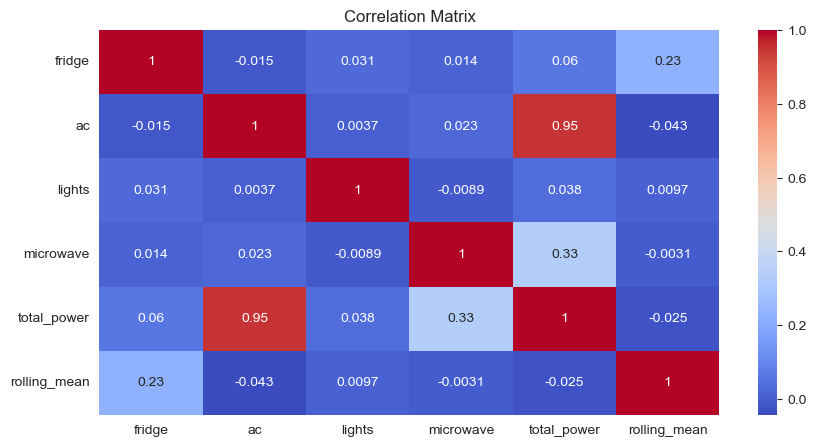

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [14]:
home = pd.read_csv("../data/HomeC.csv")

home.columns = home.columns.str.strip()
home[home.columns[0]] = pd.to_datetime(home[home.columns[0]], errors='coerce')
home.set_index(home.columns[0], inplace=True)

print("HomeC Columns:", home.columns)
home.head()

HomeC Columns: Index(['use [kW]', 'gen [kW]', 'House overall [kW]', 'Dishwasher [kW]',
       'Furnace 1 [kW]', 'Furnace 2 [kW]', 'Home office [kW]', 'Fridge [kW]',
       'Wine cellar [kW]', 'Garage door [kW]', 'Kitchen 12 [kW]',
       'Kitchen 14 [kW]', 'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]',
       'Microwave [kW]', 'Living room [kW]', 'Solar [kW]', 'temperature',
       'icon', 'humidity', 'visibility', 'summary', 'apparentTemperature',
       'pressure', 'windSpeed', 'cloudCover', 'windBearing', 'precipIntensity',
       'dewPoint', 'precipProbability'],
      dtype='object')


C:\Users\DELL\AppData\Local\Temp\ipykernel_14340\1786612873.py:1: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  home = pd.read_csv("../data/HomeC.csv")


,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
time,,,,,,,,,,,,,,,,,,,,,
1970-01-01 00:00:01.451624400,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,0.013083,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1970-01-01 00:00:01.451624401,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,0.013117,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1970-01-01 00:00:01.451624402,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,0.013083,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1970-01-01 00:00:01.451624403,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,0.013000,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1970-01-01 00:00:01.451624404,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,0.012783,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [15]:
print(home.columns)

Index(['use [kW]', 'gen [kW]', 'House overall [kW]', 'Dishwasher [kW]',
       'Furnace 1 [kW]', 'Furnace 2 [kW]', 'Home office [kW]', 'Fridge [kW]',
       'Wine cellar [kW]', 'Garage door [kW]', 'Kitchen 12 [kW]',
       'Kitchen 14 [kW]', 'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]',
       'Microwave [kW]', 'Living room [kW]', 'Solar [kW]', 'temperature',
       'icon', 'humidity', 'visibility', 'summary', 'apparentTemperature',
       'pressure', 'windSpeed', 'cloudCover', 'windBearing', 'precipIntensity',
       'dewPoint', 'precipProbability'],
      dtype='object')


In [16]:

appliance_cols = [col for col in home.columns if '[kW]' in col]


appliance_usage = home[appliance_cols].mean()

appliance_usage.sort_values(ascending=False)

use [kW]              0.956471
House overall [kW]    0.956471
Furnace 2 [kW]        0.221994
Furnace 1 [kW]        0.192918
Home office [kW]      0.078773
gen [kW]              0.066935
Solar [kW]            0.066933
Barn [kW]             0.063928
Fridge [kW]           0.053771
Living room [kW]      0.039231
Dishwasher [kW]       0.033798
Wine cellar [kW]      0.020883
Well [kW]             0.017044
Garage door [kW]      0.013710
Microwave [kW]        0.009625
Kitchen 14 [kW]       0.007424
Kitchen 12 [kW]       0.002332
Kitchen 38 [kW]       0.000010
dtype: float64

In [17]:
kitchen_cols = [col for col in home.columns if 'Kitchen' in col]

home[kitchen_cols].mean()

Kitchen 12 [kW]    0.002332
Kitchen 14 [kW]    0.007424
Kitchen 38 [kW]    0.000010
dtype: float64

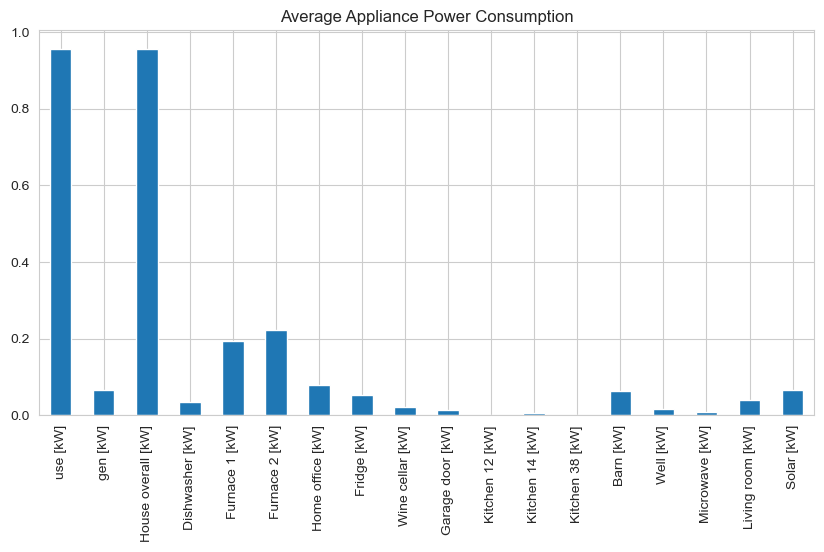

In [18]:
appliance_usage.plot(kind='bar')
plt.title("Average Appliance Power Consumption")
plt.show()

In [19]:


from sklearn.preprocessing import MinMaxScaler

numeric_cols = df.select_dtypes(include=['number']).columns

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[numeric_cols])

print("Normalization Completed")
print("Scaled Data Shape:", df_scaled.shape)

Normalization Completed
Scaled Data Shape: (4321, 6)


In [20]:


print("Original Data (First 5 rows):")
print(df[numeric_cols].head())

print("\nScaled Data (First 5 rows):")
print(pd.DataFrame(df_scaled, columns=numeric_cols).head())

Original Data (First 5 rows):
                     fridge    ac  lights  microwave  total_power  \
timestamp                                                           
2023-01-01 00:00:00     119     0      73          0          192   
2023-01-01 01:00:00     134     0       0          0          134   
2023-01-01 02:00:00       0  1551      73          0         1624   
2023-01-01 03:00:00       0     0      66          0           66   
2023-01-01 04:00:00      83     0      86          0          169   

                     rolling_mean  
timestamp                          
2023-01-01 00:00:00           NaN  
2023-01-01 01:00:00           NaN  
2023-01-01 02:00:00           NaN  
2023-01-01 03:00:00           NaN  
2023-01-01 04:00:00           NaN  

Scaled Data (First 5 rows):
     fridge        ac    lights  microwave  total_power  rolling_mean
0  0.597990  0.000000  0.737374        0.0     0.049548           NaN
1  0.673367  0.000000  0.000000        0.0     0.034581          

In [21]:


from sklearn.model_selection import train_test_split

X = df[numeric_cols]
y = df[numeric_cols[0]]   # target = first numeric column

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)

Training Set Size: (3456, 6)
Testing Set Size: (865, 6)
